In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime


from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print("All imports successful.")

All imports successful.


In [6]:
def load_all_tables(directory_path='../data/raw/', verbose=True):
    '''
    Load all 8 Home Credit tables into global variables.
    
    Inputs:
        directory_path: str, path to folder containing CSVs
        verbose: bool, whether to print progress and shapes
    '''
    if verbose:
        print("Loading all tables...")
    start = datetime.now()

    global application_train, application_test, bureau, bureau_balance
    global cc_balance, installments_payments, POS_CASH_balance, previous_application

    application_train = pd.read_csv(directory_path + 'application_train.csv')
    if verbose: print(f"  1/8 application_train     {application_train.shape}")

    application_test = pd.read_csv(directory_path + 'application_test.csv')
    if verbose: print(f"  2/8 application_test      {application_test.shape}")

    bureau = pd.read_csv(directory_path + 'bureau.csv')
    if verbose: print(f"  3/8 bureau                {bureau.shape}")

    bureau_balance = pd.read_csv(directory_path + 'bureau_balance.csv')
    if verbose: print(f"  4/8 bureau_balance        {bureau_balance.shape}")

    cc_balance = pd.read_csv(directory_path + 'credit_card_balance.csv')
    if verbose: print(f"  5/8 credit_card_balance   {cc_balance.shape}")

    installments_payments = pd.read_csv(directory_path + 'installments_payments.csv')
    if verbose: print(f"  6/8 installments_payments {installments_payments.shape}")

    POS_CASH_balance = pd.read_csv(directory_path + 'POS_CASH_balance.csv')
    if verbose: print(f"  7/8 POS_CASH_balance      {POS_CASH_balance.shape}")

    previous_application = pd.read_csv(directory_path + 'previous_application.csv')
    if verbose: print(f"  8/8 previous_application  {previous_application.shape}")

    elapsed = datetime.now() - start
    if verbose:
        print(f"\nAll 8 tables loaded in {elapsed}")
        print(f"\nMemory usage summary:")
        for name, df in [
            ('application_train', application_train),
            ('application_test', application_test),
            ('bureau', bureau),
            ('bureau_balance', bureau_balance),
            ('cc_balance', cc_balance),
            ('installments_payments', installments_payments),
            ('POS_CASH_balance', POS_CASH_balance),
            ('previous_application', previous_application)
        ]:
            mb = df.memory_usage(deep=True).sum() / 1024**2
            print(f"  {name:<30} {mb:>8.1f} MB")

load_all_tables()

Loading all tables...
  1/8 application_train     (307511, 122)
  2/8 application_test      (48744, 121)
  3/8 bureau                (1716428, 17)
  4/8 bureau_balance        (27299925, 3)
  5/8 credit_card_balance   (3840312, 23)
  6/8 installments_payments (13605401, 8)
  7/8 POS_CASH_balance      (10001358, 8)
  8/8 previous_application  (1670214, 37)

All 8 tables loaded in 0:00:35.154825

Memory usage summary:
  application_train                 325.2 MB
  application_test                   51.2 MB
  bureau                            271.5 MB
  bureau_balance                    650.9 MB
  cc_balance                        696.2 MB
  installments_payments             830.4 MB
  POS_CASH_balance                  669.9 MB
  previous_application              671.8 MB


In [7]:
print("=" * 60)
print("TARGET DISTRIBUTION — application_train")
print("=" * 60)

target_counts = application_train['TARGET'].value_counts()
target_pct = application_train['TARGET'].value_counts(normalize=True) * 100

print(f"\nCount:")
print(f"  Non-defaulters (0): {target_counts[0]:,}")
print(f"  Defaulters     (1): {target_counts[1]:,}")
print(f"\nPercentage:")
print(f"  Non-defaulters (0): {target_pct[0]:.2f}%")
print(f"  Defaulters     (1): {target_pct[1]:.2f}%")
print(f"\nClass imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")

fig = px.pie(
    values=target_counts.values,
    names=['Non-Defaulter (0)', 'Defaulter (1)'],
    title='Target Distribution — Loan Default Rate',
    color_discrete_sequence=['#2196F3', '#F44336'],
    hole=0.4
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(showlegend=True)
fig.show()

TARGET DISTRIBUTION — application_train

Count:
  Non-defaulters (0): 282,686
  Defaulters     (1): 24,825

Percentage:
  Non-defaulters (0): 91.93%
  Defaulters     (1): 8.07%

Class imbalance ratio: 11.4:1


In [10]:
def nan_df_create(data):
    '''Create DataFrame of NaN percentages per column, sorted descending.'''
    nan_percentages = data.isna().sum() * 100 / len(data)
    df = pd.DataFrame({
        'column': nan_percentages.index,
        'percent': nan_percentages.values
    })
    df.sort_values(by='percent', ascending=False, inplace=True)
    return df


def plot_nan_percent(df_nan, title_name, figsize=(20,8), rotation=90):
    '''Bar plot of NaN percentages for columns that have missing values.'''
    if df_nan.percent.sum() != 0:
        n_missing = df_nan[df_nan['percent'] != 0].shape[0]
        print(f"Columns with NaN values: {n_missing}")
        plt.figure(figsize=figsize, tight_layout=True)
        sns.barplot(x='column', y='percent',
                    data=df_nan[df_nan['percent'] > 0])
        plt.xticks(rotation=rotation)
        plt.xlabel('Column Name')
        plt.ylabel('Percentage of NaN values')
        plt.title(f'NaN % in {title_name}')
        plt.show()
    else:
        print(f"{title_name}: no NaN values.")


print("Helper functions defined.")

Helper functions defined.


MISSING VALUE ANALYSIS — application_train

Total columns:          122
Columns with NaN:       67
Columns without NaN:    55

Top 20 columns by missing %:
                  column  percent
         COMMONAREA_MEDI  69.8723
          COMMONAREA_AVG  69.8723
         COMMONAREA_MODE  69.8723
NONLIVINGAPARTMENTS_MODE  69.4330
 NONLIVINGAPARTMENTS_AVG  69.4330
NONLIVINGAPARTMENTS_MEDI  69.4330
      FONDKAPREMONT_MODE  68.3862
   LIVINGAPARTMENTS_MODE  68.3550
    LIVINGAPARTMENTS_AVG  68.3550
   LIVINGAPARTMENTS_MEDI  68.3550
           FLOORSMIN_AVG  67.8486
          FLOORSMIN_MODE  67.8486
          FLOORSMIN_MEDI  67.8486
        YEARS_BUILD_MEDI  66.4978
        YEARS_BUILD_MODE  66.4978
         YEARS_BUILD_AVG  66.4978
             OWN_CAR_AGE  65.9908
           LANDAREA_MEDI  59.3767
           LANDAREA_MODE  59.3767
            LANDAREA_AVG  59.3767

Missingness severity breakdown:
  >60% missing  (likely drop):      17 columns
  40-60% missing (use carefully):   32 columns
  1

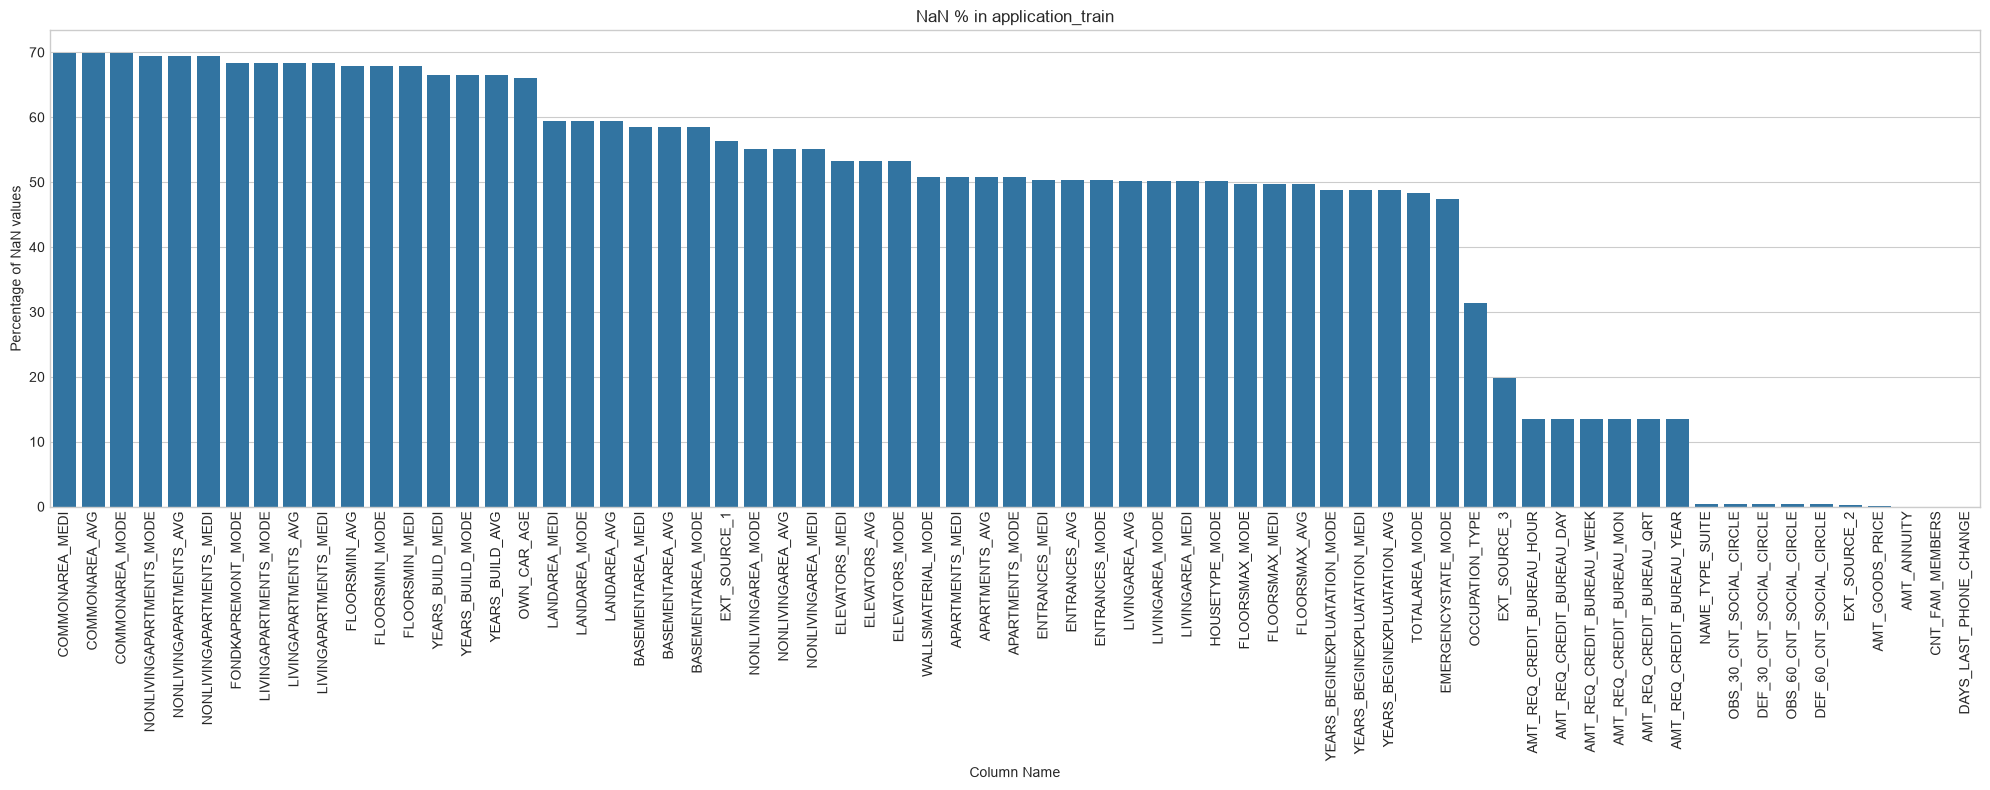

In [11]:
print("=" * 60)
print("MISSING VALUE ANALYSIS — application_train")
print("=" * 60)

nan_train = nan_df_create(application_train)

total_cols = application_train.shape[1]
cols_with_nan = nan_train[nan_train['percent'] > 0].shape[0]
cols_no_nan = total_cols - cols_with_nan

print(f"\nTotal columns:          {total_cols}")
print(f"Columns with NaN:       {cols_with_nan}")
print(f"Columns without NaN:    {cols_no_nan}")
print(f"\nTop 20 columns by missing %:")
print(nan_train[nan_train['percent'] > 0].head(20).to_string(index=False))

# Buckets — how bad is the missingness?
over_60 = nan_train[nan_train['percent'] > 60].shape[0]
btw_40_60 = nan_train[(nan_train['percent'] > 40) & 
                       (nan_train['percent'] <= 60)].shape[0]
btw_10_40 = nan_train[(nan_train['percent'] > 10) & 
                       (nan_train['percent'] <= 40)].shape[0]
under_10 = nan_train[(nan_train['percent'] > 0) & 
                      (nan_train['percent'] <= 10)].shape[0]

print(f"\nMissingness severity breakdown:")
print(f"  >60% missing  (likely drop):      {over_60} columns")
print(f"  40-60% missing (use carefully):   {btw_40_60} columns")
print(f"  10-40% missing (impute/bin):      {btw_10_40} columns")
print(f"  <10% missing  (handle normally):  {under_10} columns")

# Visual
plot_nan_percent(nan_train, 'application_train')

DAYS_EMPLOYED ANOMALY ANALYSIS

DAYS_EMPLOYED basic stats:
count   307511.0000
mean     63815.0459
std     141275.7665
min     -17912.0000
25%      -2760.0000
50%      -1213.0000
75%       -289.0000
max     365243.0000
Name: DAYS_EMPLOYED, dtype: float64

Anomalous value (365243) count: 55,374
Anomalous value percentage:     18.01%

Bad rate for anomalous group:   5.40%
Bad rate for normal group:      8.66%

Conclusion: normal group defaults at 1.6x the rate of anomalous group

Fixed: created DAYS_EMPLOYED_ANOM flag (55,374 flagged)
Fixed: replaced 365243 with NaN in DAYS_EMPLOYED


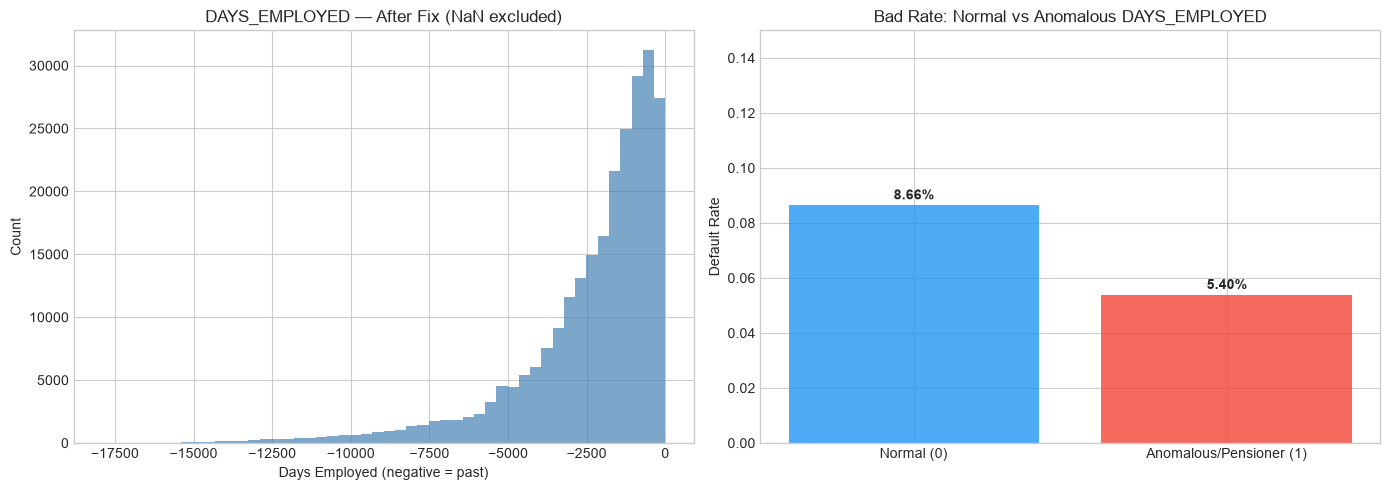


DAYS_EMPLOYED anomaly handled successfully.


In [12]:
print("=" * 60)
print("DAYS_EMPLOYED ANOMALY ANALYSIS")
print("=" * 60)

print(f"\nDAYS_EMPLOYED basic stats:")
print(application_train['DAYS_EMPLOYED'].describe())

anomaly_count = (application_train['DAYS_EMPLOYED'] == 365243).sum()
anomaly_pct = anomaly_count / len(application_train) * 100

print(f"\nAnomalous value (365243) count: {anomaly_count:,}")
print(f"Anomalous value percentage:     {anomaly_pct:.2f}%")

# Bad rate comparison — anomalous vs normal
anomaly_bad_rate = application_train[
    application_train['DAYS_EMPLOYED'] == 365243
]['TARGET'].mean()

normal_bad_rate = application_train[
    application_train['DAYS_EMPLOYED'] != 365243
]['TARGET'].mean()

print(f"\nBad rate for anomalous group:   {anomaly_bad_rate:.2%}")
print(f"Bad rate for normal group:      {normal_bad_rate:.2%}")
print(f"\nConclusion: anomalous group defaults at "
      f"{anomaly_bad_rate/normal_bad_rate:.1f}x the rate of normal group"
      if anomaly_bad_rate > normal_bad_rate 
      else f"\nConclusion: normal group defaults at "
      f"{normal_bad_rate/anomaly_bad_rate:.1f}x the rate of anomalous group")

# Fix it
application_train['DAYS_EMPLOYED_ANOM'] = (
    application_train['DAYS_EMPLOYED'] == 365243
).astype(int)
application_train['DAYS_EMPLOYED'] = application_train['DAYS_EMPLOYED'].replace(
    365243, np.nan
)

print(f"\nFixed: created DAYS_EMPLOYED_ANOM flag ({anomaly_count:,} flagged)")
print(f"Fixed: replaced 365243 with NaN in DAYS_EMPLOYED")

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before fix — just show the normal values to visualize distribution
application_train[
    application_train['DAYS_EMPLOYED'].notna()
]['DAYS_EMPLOYED'].hist(bins=50, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('DAYS_EMPLOYED — After Fix (NaN excluded)')
axes[0].set_xlabel('Days Employed (negative = past)')
axes[0].set_ylabel('Count')

# Bad rate by anomaly flag
bad_rates = application_train.groupby('DAYS_EMPLOYED_ANOM')['TARGET'].mean()
axes[1].bar(['Normal (0)', 'Anomalous/Pensioner (1)'], 
            bad_rates.values,
            color=['#2196F3', '#F44336'], alpha=0.8)
axes[1].set_title('Bad Rate: Normal vs Anomalous DAYS_EMPLOYED')
axes[1].set_ylabel('Default Rate')
axes[1].set_ylim(0, 0.15)
for i, v in enumerate(bad_rates.values):
    axes[1].text(i, v + 0.002, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDAYS_EMPLOYED anomaly handled successfully.")

I found that 18% of DAYS_EMPLOYED values were encoded as 365,243 — a placeholder for pensioners and unemployed. Rather than dropping these or treating them as missing, I investigated their default behavior and found they default at 5.4% vs 8.66% for normally employed applicants — 1.6x lower risk. I created a binary flag feature to preserve this signal and replaced the anomalous values with NaN for the continuous feature, allowing WOE binning to handle the missing values as a separate bin.

EXT_SOURCE ANALYSIS — Strongest Predictors

Missing rates:
  EXT_SOURCE_1: 56.38% missing
  EXT_SOURCE_2: 0.21% missing
  EXT_SOURCE_3: 19.83% missing

Correlation with TARGET:
  EXT_SOURCE_1: -0.1553
  EXT_SOURCE_2: -0.1605
  EXT_SOURCE_3: -0.1789


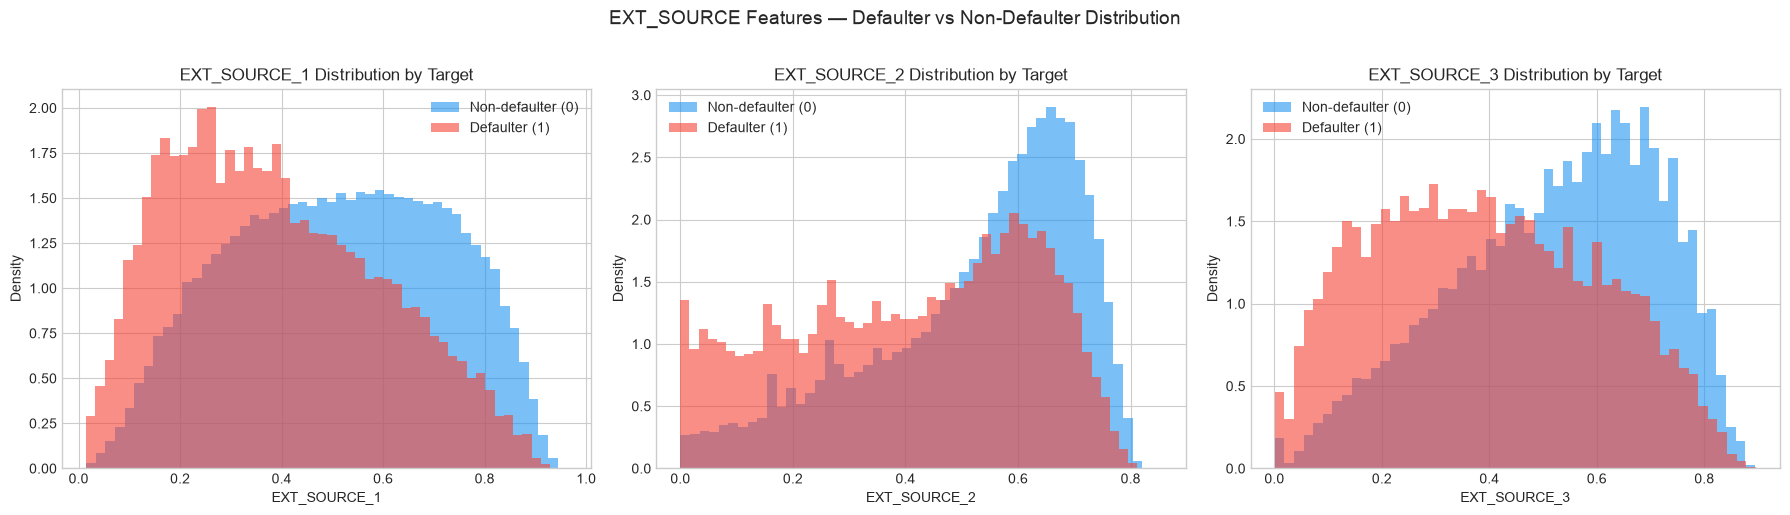

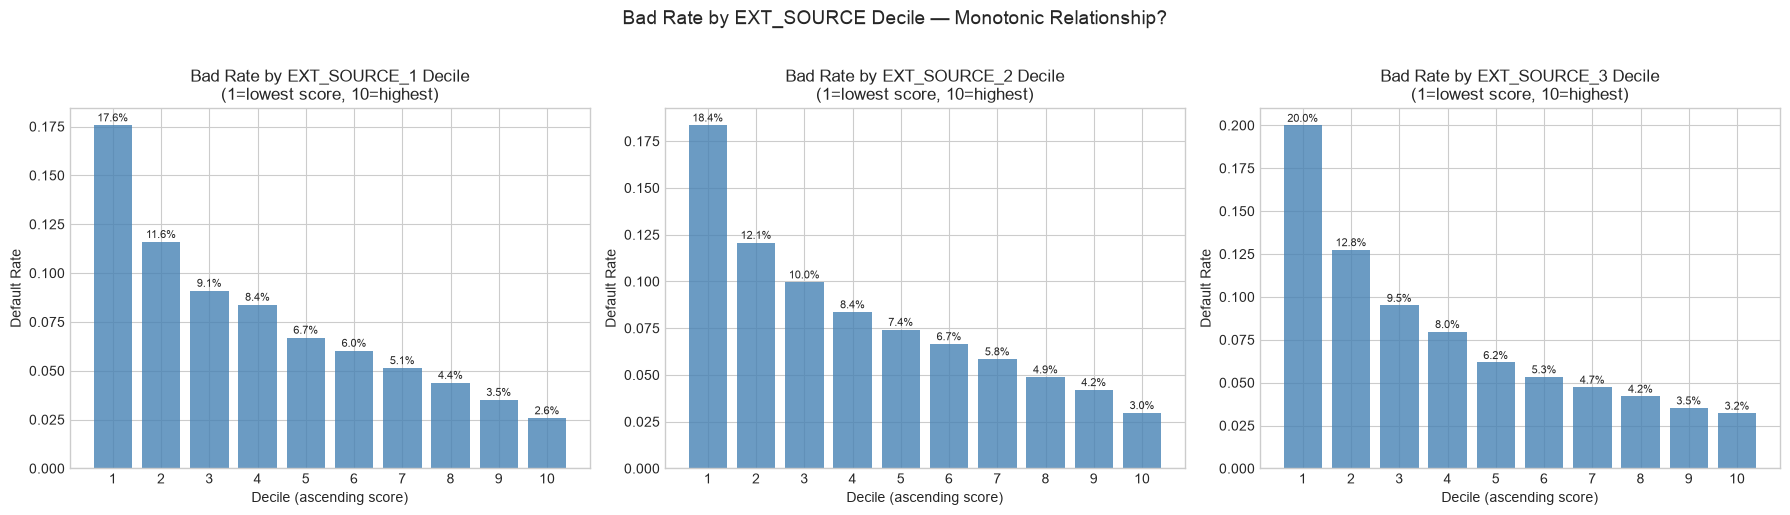


Key insight: negative correlation means higher EXT_SOURCE = lower default risk
These three features will be the anchor variables in the scorecard.


In [13]:
print("=" * 60)
print("EXT_SOURCE ANALYSIS — Strongest Predictors")
print("=" * 60)

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Missing rates
print("\nMissing rates:")
for col in ext_cols:
    missing = application_train[col].isna().mean() * 100
    print(f"  {col}: {missing:.2f}% missing")

# Correlation with TARGET
print("\nCorrelation with TARGET:")
for col in ext_cols:
    corr = application_train[col].corr(application_train['TARGET'])
    print(f"  {col}: {corr:.4f}")

# Distribution by target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(ext_cols):
    application_train[application_train['TARGET']==0][col].hist(
        bins=50, ax=axes[i], alpha=0.6, label='Non-defaulter (0)',
        color='#2196F3', density=True
    )
    application_train[application_train['TARGET']==1][col].hist(
        bins=50, ax=axes[i], alpha=0.6, label='Defaulter (1)',
        color='#F44336', density=True
    )
    axes[i].set_title(f'{col} Distribution by Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('EXT_SOURCE Features — Defaulter vs Non-Defaulter Distribution',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Bad rate by decile for each EXT_SOURCE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(ext_cols):
    temp = application_train[[col, 'TARGET']].dropna()
    temp[col+'_decile'] = pd.qcut(temp[col], 10, duplicates='drop',
                                   labels=False)
    bad_rate_by_decile = temp.groupby(col+'_decile')['TARGET'].mean()
    axes[i].bar(range(len(bad_rate_by_decile)),
                bad_rate_by_decile.values,
                color='steelblue', alpha=0.8)
    axes[i].set_title(f'Bad Rate by {col} Decile\n(1=lowest score, 10=highest)')
    axes[i].set_xlabel('Decile (ascending score)')
    axes[i].set_ylabel('Default Rate')
    axes[i].set_xticks(range(len(bad_rate_by_decile)))
    axes[i].set_xticklabels([str(d+1) for d in range(len(bad_rate_by_decile))])
    for j, v in enumerate(bad_rate_by_decile.values):
        axes[i].text(j, v + 0.002, f'{v:.1%}',
                    ha='center', fontsize=8)

plt.suptitle('Bad Rate by EXT_SOURCE Decile — Monotonic Relationship?',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nKey insight: negative correlation means higher EXT_SOURCE = lower default risk")
print("These three features will be the anchor variables in the scorecard.")

EXT_SOURCE_3 was the strongest single predictor with a -0.179 correlation with default and a nearly perfect monotonic bad rate relationship across deciles — 20% bad rate in the lowest decile dropping to 3.2% in the highest. Combined with EXT_SOURCE_2 which had only 0.21% missing values, these two features anchor the scorecard. I combined all three into a weighted average feature for the final model.

CATEGORICAL FEATURE ANALYSIS


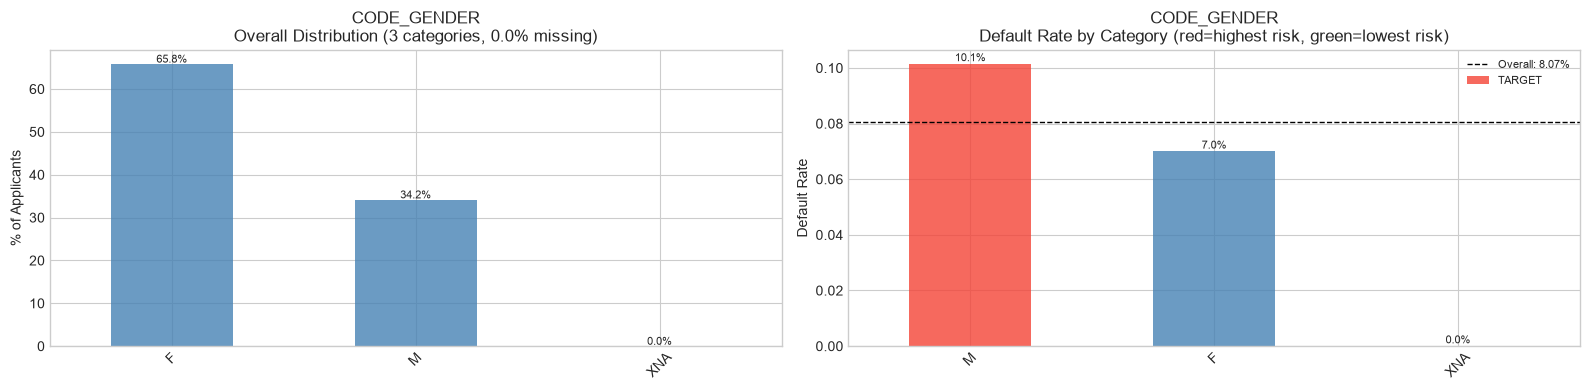


CODE_GENDER — bad rate range: 0.00% to 10.14% (spread: 10.14%)
--------------------------------------------------


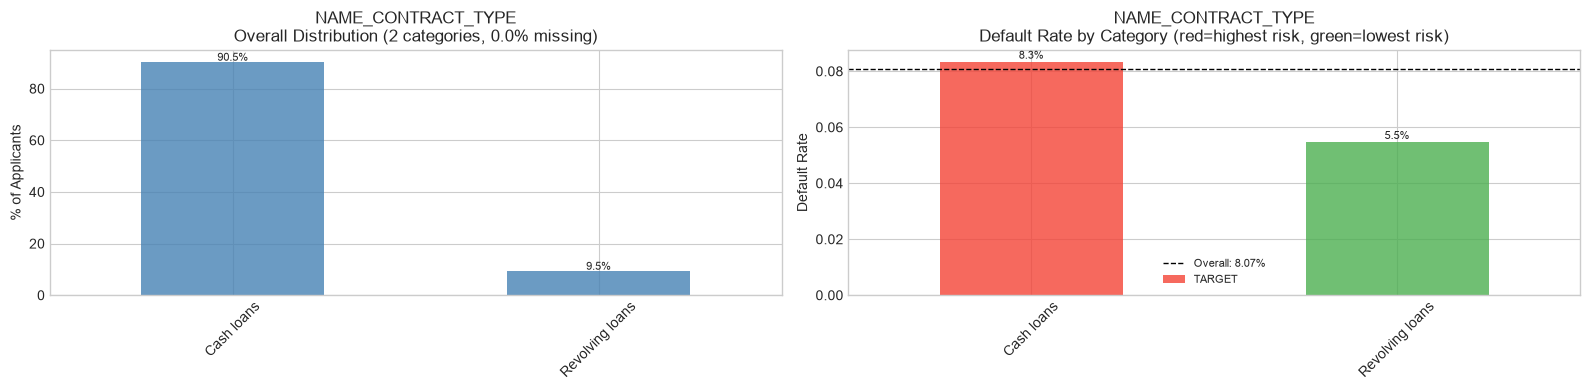


NAME_CONTRACT_TYPE — bad rate range: 5.48% to 8.35% (spread: 2.87%)
--------------------------------------------------


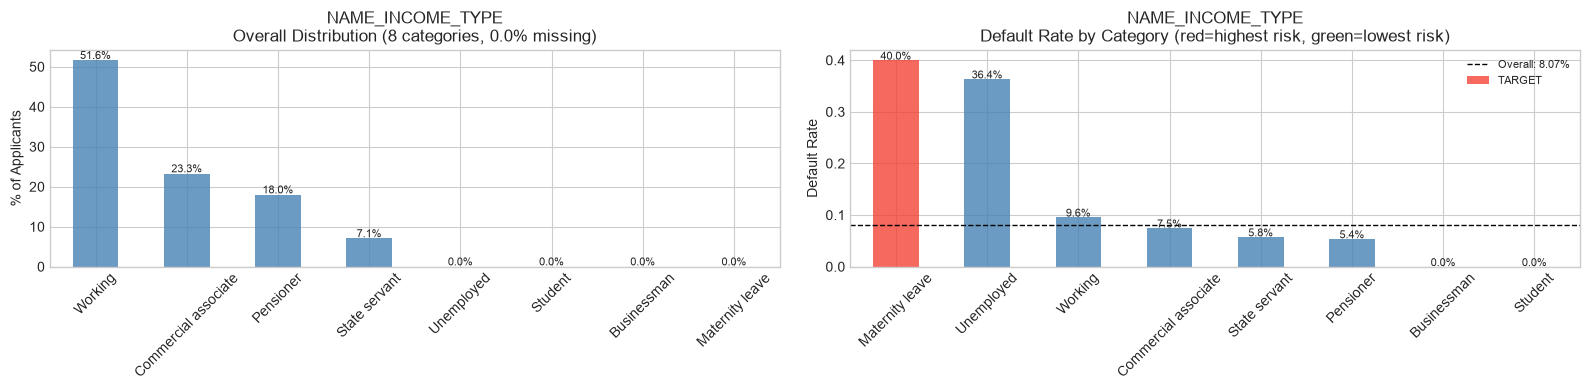


NAME_INCOME_TYPE — bad rate range: 0.00% to 40.00% (spread: 40.00%)
--------------------------------------------------


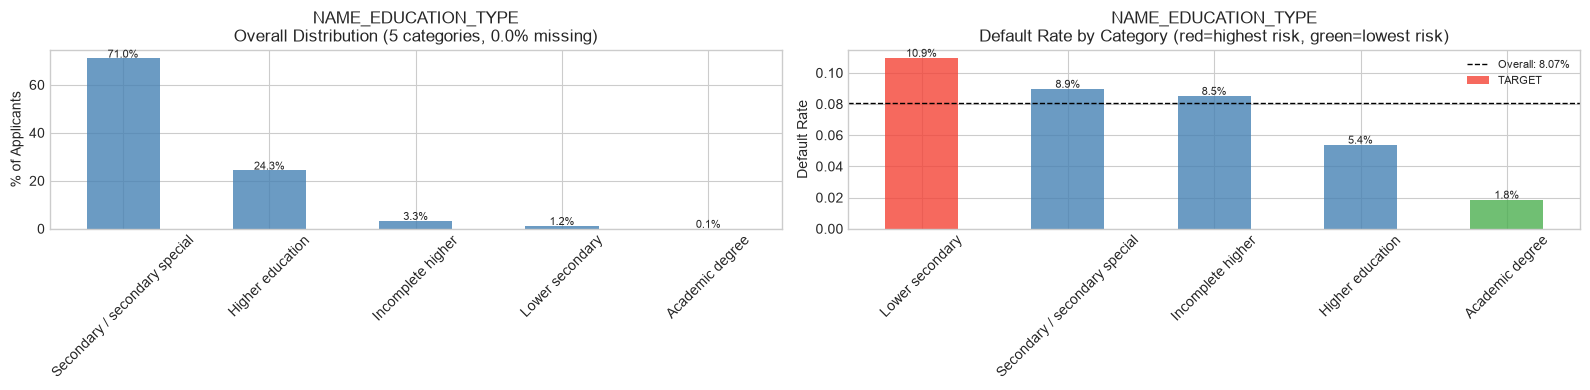


NAME_EDUCATION_TYPE — bad rate range: 1.83% to 10.93% (spread: 9.10%)
--------------------------------------------------


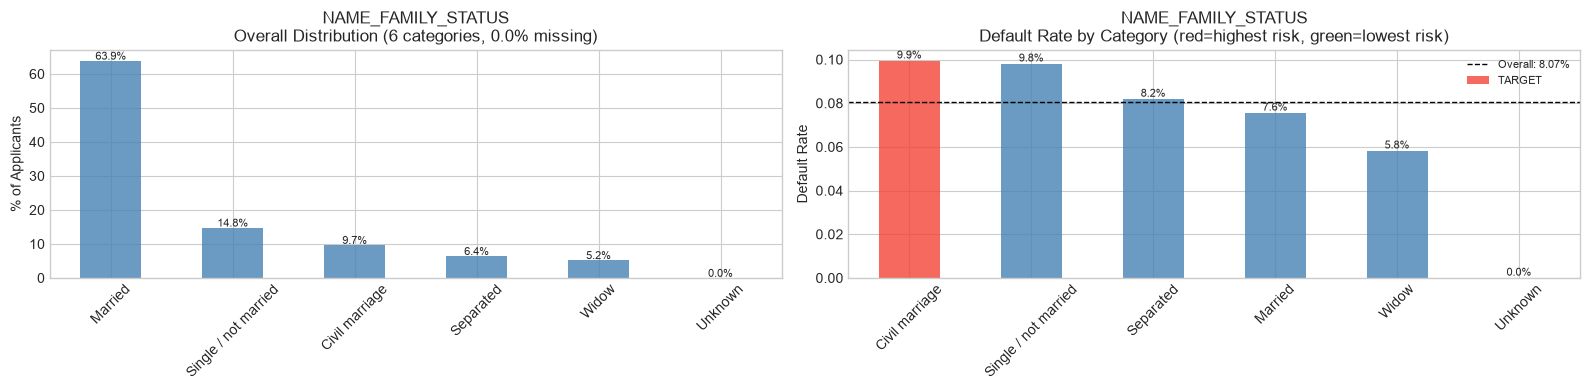


NAME_FAMILY_STATUS — bad rate range: 0.00% to 9.94% (spread: 9.94%)
--------------------------------------------------


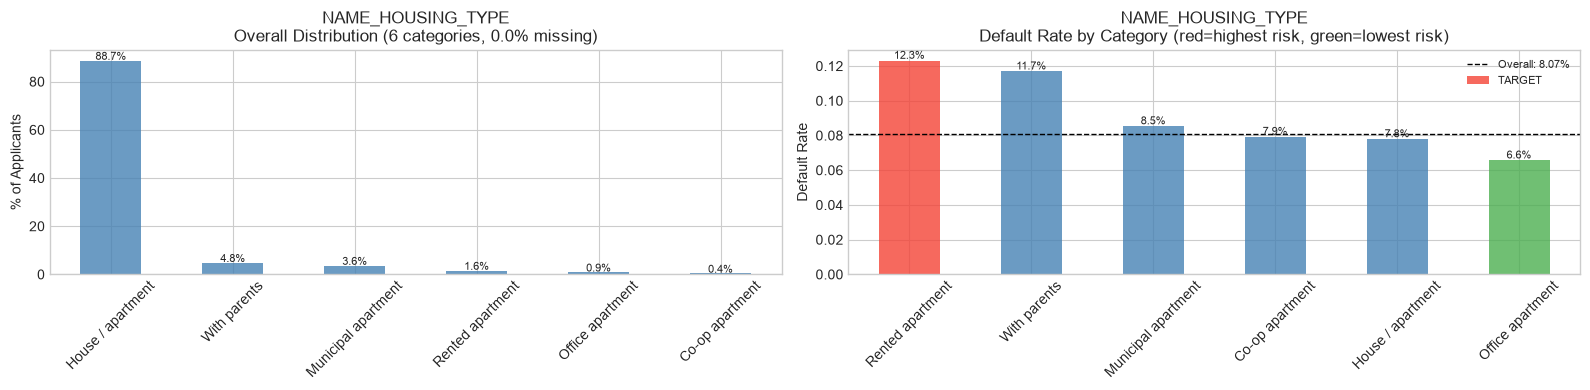


NAME_HOUSING_TYPE — bad rate range: 6.57% to 12.31% (spread: 5.74%)
--------------------------------------------------


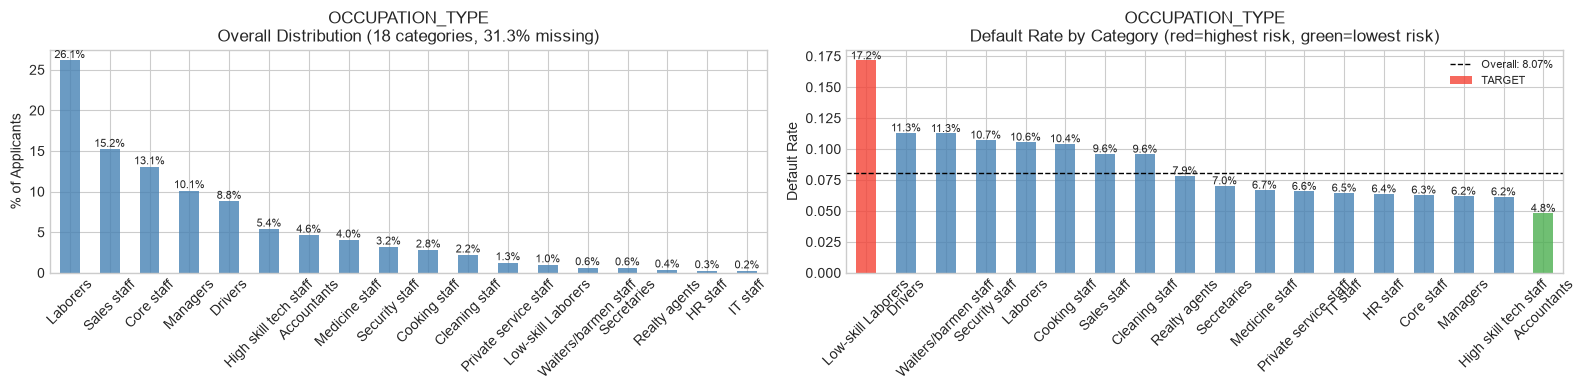


OCCUPATION_TYPE — bad rate range: 4.83% to 17.15% (spread: 12.32%)
--------------------------------------------------


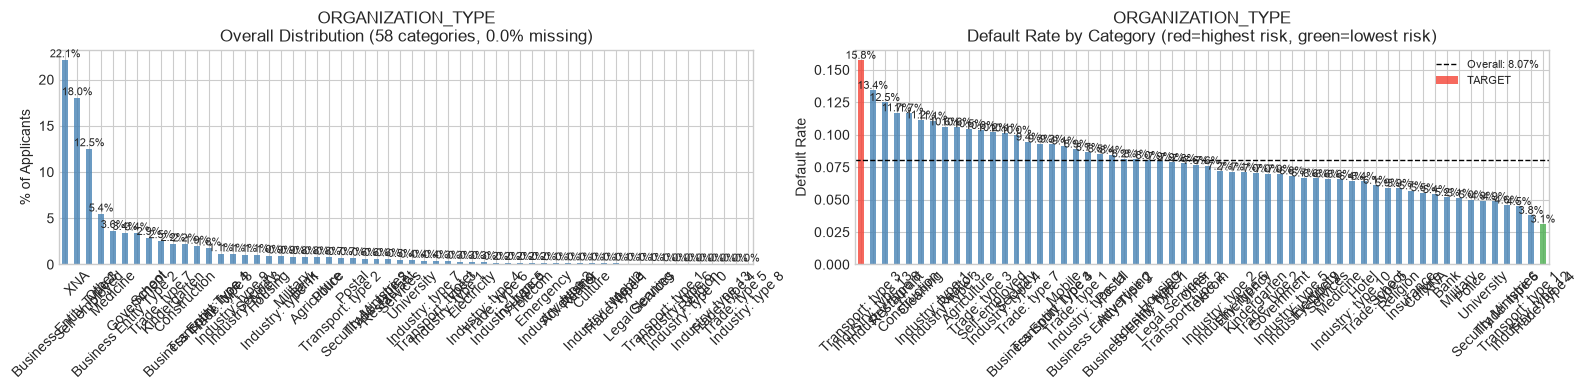


ORGANIZATION_TYPE — bad rate range: 3.12% to 15.75% (spread: 12.63%)
--------------------------------------------------


In [14]:
print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

cat_features = [
    'CODE_GENDER',
    'NAME_CONTRACT_TYPE', 
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

for col in cat_features:
    n_unique = application_train[col].nunique()
    missing = application_train[col].isna().mean() * 100
    
    # Bad rate by category
    bad_rate = (application_train.groupby(col)['TARGET']
                .mean()
                .sort_values(ascending=False))
    
    count_dist = (application_train[col]
                  .value_counts(normalize=True) * 100)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    
    # Left: count distribution
    count_dist.plot(kind='bar', ax=axes[0], 
                    color='steelblue', alpha=0.8)
    axes[0].set_title(f'{col}\nOverall Distribution '
                      f'({n_unique} categories, {missing:.1f}% missing)')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('% of Applicants')
    axes[0].tick_params(axis='x', rotation=45)
    for p in axes[0].patches:
        axes[0].text(p.get_x() + p.get_width()/2,
                    p.get_height() + 0.3,
                    f'{p.get_height():.1f}%',
                    ha='center', fontsize=8)
    
    # Right: bad rate by category
    colors = ['#F44336' if v == bad_rate.max() 
              else '#4CAF50' if v == bad_rate.min() 
              else 'steelblue' 
              for v in bad_rate.values]
    bad_rate.plot(kind='bar', ax=axes[1], 
                  color=colors, alpha=0.8)
    axes[1].set_title(f'{col}\nDefault Rate by Category '
                      f'(red=highest risk, green=lowest risk)')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Default Rate')
    axes[1].axhline(y=application_train['TARGET'].mean(), 
                    color='black', linestyle='--', 
                    linewidth=1, label=f'Overall: '
                    f'{application_train["TARGET"].mean():.2%}')
    axes[1].legend(fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)
    for p in axes[1].patches:
        axes[1].text(p.get_x() + p.get_width()/2,
                    p.get_height() + 0.001,
                    f'{p.get_height():.1%}',
                    ha='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{col} — bad rate range: "
          f"{bad_rate.min():.2%} to {bad_rate.max():.2%} "
          f"(spread: {bad_rate.max()-bad_rate.min():.2%})")
    print("-" * 50)

NUMERIC FEATURE ANALYSIS


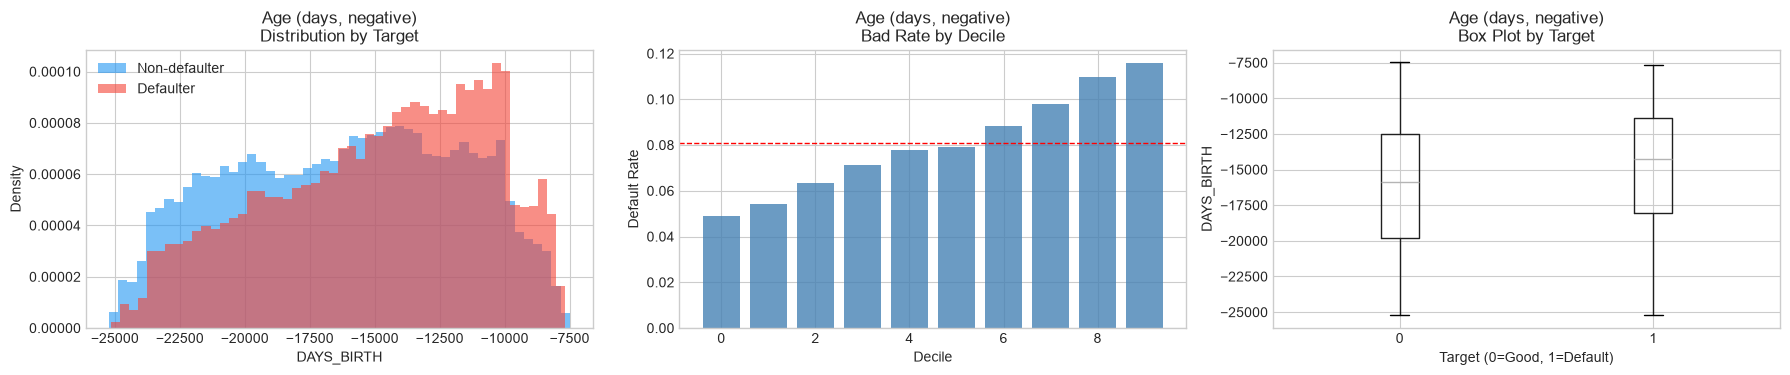


DAYS_BIRTH:
  Non-defaulter median: -15,877.0
  Defaulter median:     -14,282.0
  Difference:           -10.0%
--------------------------------------------------


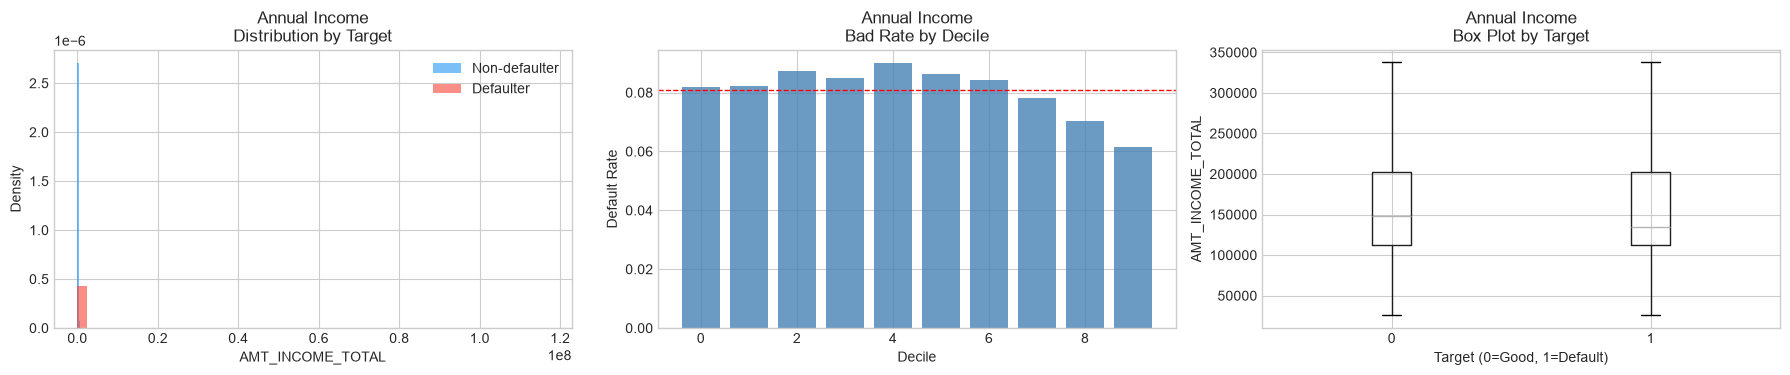


AMT_INCOME_TOTAL:
  Non-defaulter median: 148,500.0
  Defaulter median:     135,000.0
  Difference:           -9.1%
--------------------------------------------------


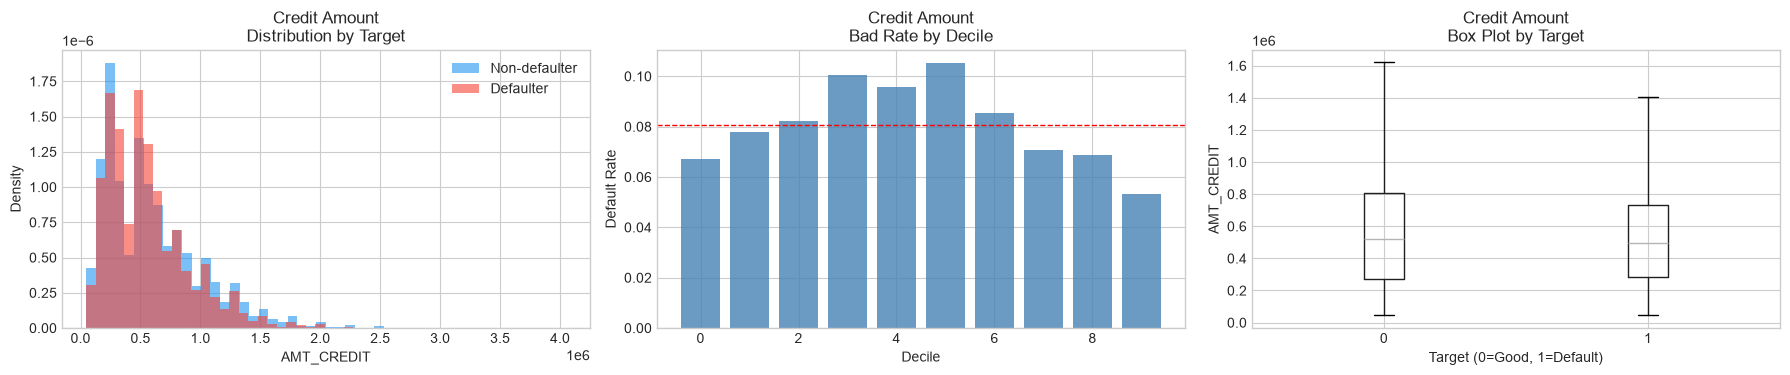


AMT_CREDIT:
  Non-defaulter median: 517,788.0
  Defaulter median:     497,520.0
  Difference:           -3.9%
--------------------------------------------------


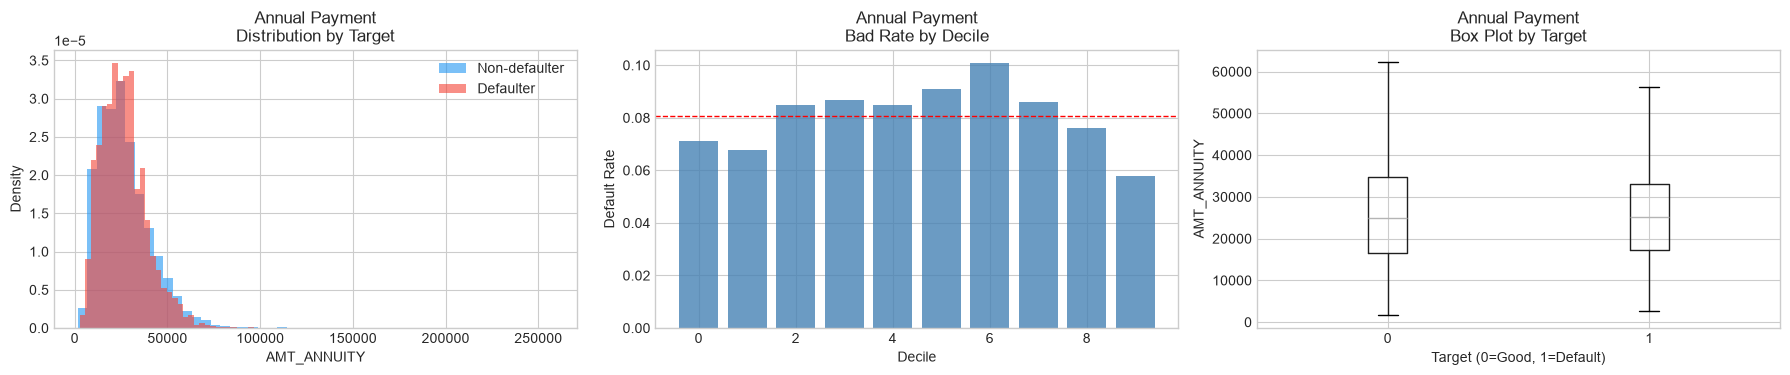


AMT_ANNUITY:
  Non-defaulter median: 24,876.0
  Defaulter median:     25,263.0
  Difference:           +1.6%
--------------------------------------------------


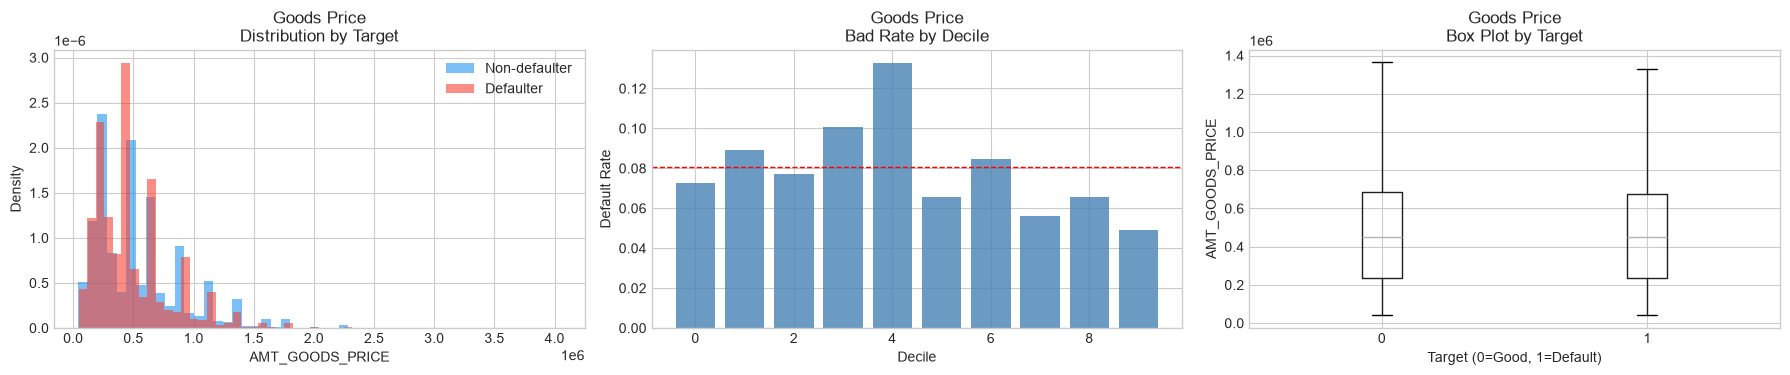


AMT_GOODS_PRICE:
  Non-defaulter median: 450,000.0
  Defaulter median:     450,000.0
  Difference:           +0.0%
--------------------------------------------------


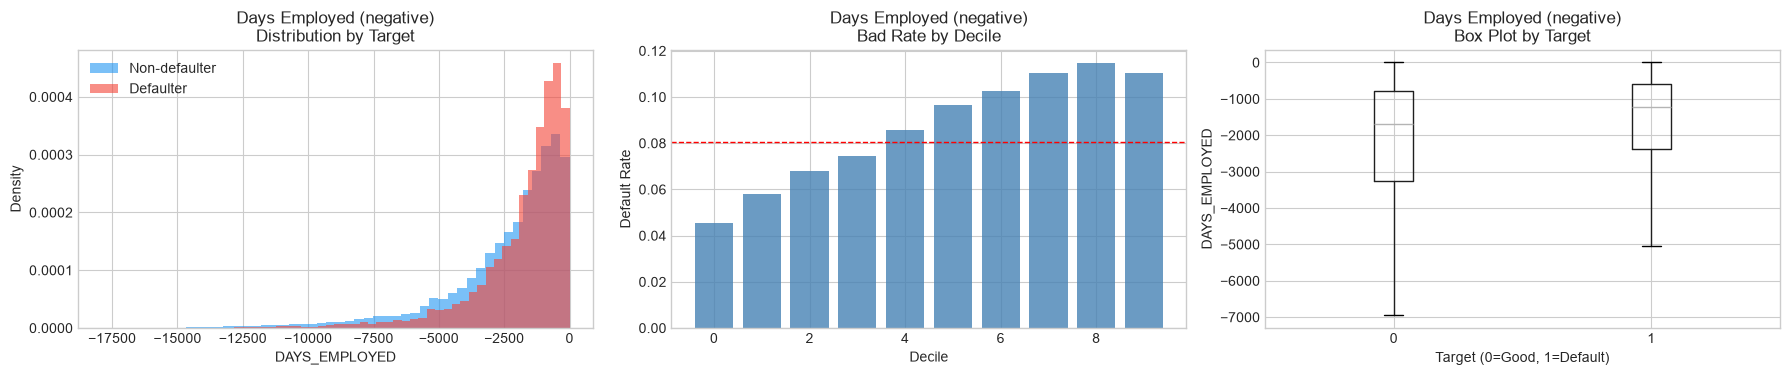


DAYS_EMPLOYED:
  Non-defaulter median: -1,691.0
  Defaulter median:     -1,230.0
  Difference:           -27.3%
--------------------------------------------------


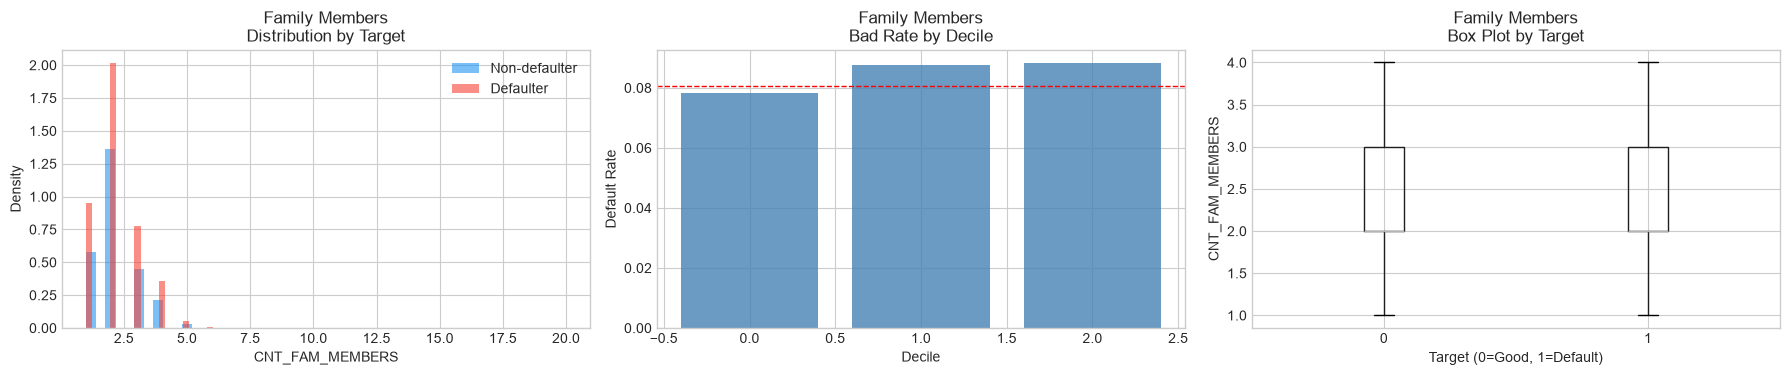


CNT_FAM_MEMBERS:
  Non-defaulter median: 2.0
  Defaulter median:     2.0
  Difference:           +0.0%
--------------------------------------------------


In [15]:
print("=" * 60)
print("NUMERIC FEATURE ANALYSIS")
print("=" * 60)

num_features = {
    'DAYS_BIRTH': 'Age (days, negative)',
    'AMT_INCOME_TOTAL': 'Annual Income',
    'AMT_CREDIT': 'Credit Amount',
    'AMT_ANNUITY': 'Annual Payment',
    'AMT_GOODS_PRICE': 'Goods Price',
    'DAYS_EMPLOYED': 'Days Employed (negative)',
    'CNT_FAM_MEMBERS': 'Family Members'
}

for col, label in num_features.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Distribution by target
    for target_val, color, name in [(0, '#2196F3', 'Non-defaulter'),
                                     (1, '#F44336', 'Defaulter')]:
        data = application_train[
            application_train['TARGET'] == target_val
        ][col].dropna()
        data.hist(bins=50, ax=axes[0], alpha=0.6,
                 label=name, color=color, density=True)
    axes[0].set_title(f'{label}\nDistribution by Target')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Density')
    axes[0].legend()

    # Bad rate by decile
    temp = application_train[[col, 'TARGET']].dropna()
    temp = temp[temp[col] != 365243]  # exclude anomaly if present
    try:
        temp[col+'_decile'] = pd.qcut(
            temp[col], 10, duplicates='drop', labels=False
        )
        bad_rate_decile = temp.groupby(
            col+'_decile'
        )['TARGET'].mean()
        axes[1].bar(range(len(bad_rate_decile)),
                   bad_rate_decile.values,
                   color='steelblue', alpha=0.8)
        axes[1].set_title(f'{label}\nBad Rate by Decile')
        axes[1].set_xlabel('Decile')
        axes[1].set_ylabel('Default Rate')
        axes[1].axhline(
            y=application_train['TARGET'].mean(),
            color='red', linestyle='--', linewidth=1
        )
    except Exception as e:
        axes[1].text(0.5, 0.5, f'Could not plot:\n{e}',
                    transform=axes[1].transAxes, ha='center')

    # Box plot by target
    application_train.boxplot(
        column=col, by='TARGET', ax=axes[2],
        showfliers=False
    )
    axes[2].set_title(f'{label}\nBox Plot by Target')
    axes[2].set_xlabel('Target (0=Good, 1=Default)')
    axes[2].set_ylabel(col)

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    # Stats comparison
    good = application_train[
        application_train['TARGET']==0
    ][col].dropna()
    bad = application_train[
        application_train['TARGET']==1
    ][col].dropna()

    print(f"\n{col}:")
    print(f"  Non-defaulter median: {good.median():,.1f}")
    print(f"  Defaulter median:     {bad.median():,.1f}")
    print(f"  Difference:           "
          f"{((bad.median()-good.median())/good.median()*100):+.1f}%")
    print("-" * 50)

Feature	Non-defaulter median	Defaulter median	Difference	Scorecard value
DAYS_BIRTH (age)	-15,877 (~43.5 yrs)	-14,282 (~39.1 yrs)	-10.0%	High ✓
AMT_INCOME_TOTAL	148,500	135,000	-9.1%	Medium ✓
AMT_CREDIT	517,788	497,520	-3.9%	Low alone
AMT_ANNUITY	24,876	25,263	+1.6%	Low alone
AMT_GOODS_PRICE	450,000	450,000	0.0%	Drop
DAYS_EMPLOYED	-1,691 (~4.6 yrs)	-1,230 (~3.4 yrs)	-27.3%	High ✓
CNT_FAM_MEMBERS	2.0	2.0	0.0%	Drop

In [17]:
print("=" * 60)
print("EDA SUMMARY — FEATURE SHORTLIST FOR SCORECARD")
print("=" * 60)

print("""
DATASET OVERVIEW
----------------
Training observations : 307,511
Features              : 122
Bad rate (TARGET=1)   : 8.07%
Class imbalance       : 11.4:1

DATA QUALITY ISSUES FOUND AND HANDLED
--------------------------------------
1. DAYS_EMPLOYED anomaly: 55,374 records (18.01%) had value
   365,243 — a placeholder for pensioners/unemployed.
   Action: Created DAYS_EMPLOYED_ANOM binary flag.
           Replaced 365,243 with NaN.
   Finding: Pensioners default at 5.40% vs 8.66% for employed
            — lower risk, flag is a meaningful feature.

2. Missing values: 67 of 122 columns have missing data.
   - 17 columns >60% missing (building characteristics) → DROP
   - 32 columns 40-60% missing → handle via WOE binning
   - 18 columns <40% missing → WOE binning handles automatically

FEATURE SHORTLIST — MAIN TABLE
--------------------------------
Tier 1 (strongest predictors):
  EXT_SOURCE_3       corr=-0.179, 19.83% missing
  EXT_SOURCE_2       corr=-0.161, 0.21% missing
  EXT_SOURCE_1       corr=-0.155, 56.38% missing
  DAYS_BIRTH         10.0% median age difference
  DAYS_EMPLOYED      27.3% median employment difference
  DAYS_EMPLOYED_ANOM 5.40% vs 8.66% bad rate

Tier 2 (moderate, use as engineered ratios):
  AMT_CREDIT / AMT_INCOME_TOTAL  → CREDIT_INCOME_RATIO
  AMT_ANNUITY / AMT_INCOME_TOTAL → ANNUITY_INCOME_RATIO
  AMT_ANNUITY / AMT_CREDIT       → CREDIT_TERM

Tier 3 (categorical features with high spread):
  ORGANIZATION_TYPE   spread=12.63%
  OCCUPATION_TYPE     spread=12.32%
  NAME_FAMILY_STATUS  spread=9.94%
  NAME_EDUCATION_TYPE spread=9.10%
  NAME_HOUSING_TYPE   spread=5.74%

FEATURES TO DROP (no signal):
  AMT_GOODS_PRICE     0.0% median difference, non-monotonic
  CNT_FAM_MEMBERS     0.0% median difference, flat decile chart
  CODE_GENDER         Predictive but ECOA fair lending risk
  17 building characteristic columns (>60% missing)

NEXT STEPS → notebook 02_feature_engineering.ipynb
  1. Engineer ratio features
  2. Aggregate subsidiary tables to SK_ID_CURR level
  3. Join all features to application_train
  4. WOE/IV feature selection via optbinning
""")

print("EDA complete. Proceed to 02_feature_engineering.ipynb")

EDA SUMMARY — FEATURE SHORTLIST FOR SCORECARD

DATASET OVERVIEW
----------------
Training observations : 307,511
Features              : 122
Bad rate (TARGET=1)   : 8.07%
Class imbalance       : 11.4:1

DATA QUALITY ISSUES FOUND AND HANDLED
--------------------------------------
1. DAYS_EMPLOYED anomaly: 55,374 records (18.01%) had value
   365,243 — a placeholder for pensioners/unemployed.
   Action: Created DAYS_EMPLOYED_ANOM binary flag.
           Replaced 365,243 with NaN.
   Finding: Pensioners default at 5.40% vs 8.66% for employed
            — lower risk, flag is a meaningful feature.

2. Missing values: 67 of 122 columns have missing data.
   - 17 columns >60% missing (building characteristics) → DROP
   - 32 columns 40-60% missing → handle via WOE binning
   - 18 columns <40% missing → WOE binning handles automatically

FEATURE SHORTLIST — MAIN TABLE
--------------------------------
Tier 1 (strongest predictors):
  EXT_SOURCE_3       corr=-0.179, 19.83% missing
  EXT_SOURCE_